## <center>Problem Sheet #5</center>


<img src="tanareletmod.gif" width="700">


##  Numerical Linear Algebra
### Solving equation $Ax=b$ (warmup MATLAB examples)
<br>

This material is based on the first four lectures entitled <a href="https://people.maths.ox.ac.uk/trefethen/videos.html">Scientific Computing for DPhil Students</a> given by Professor Trefethen at University of Oxford. It's worth binge-watching since it is a great stuff!

In [1]:
clear all
format long
A=randn(500);
b=ones(500,1);
x=A\b;
solution=A*x-b;
solution(1:4)
whos

ans =

   1.08801856413265e-13
   9.99200722162641e-14
  -9.70334923522387e-14
  -1.13020703906841e-13

Variables in the current scope:

   Attr Name          Size                     Bytes  Class
   ==== ====          ====                     =====  ===== 
        A           500x500                  2000000  double
        ans           4x1                         32  double
        b           500x1                       4000  double
        solution    500x1                       4000  double
        x           500x1                       4000  double

Total is 251504 elements using 2012032 bytes



D =

Compressed Column Sparse (rows = 3, cols = 3, nnz = 6 [67%])

  (1, 1) ->  1.00
  (2, 1) ->  3.00
  (2, 2) ->  4.00
  (3, 2) ->  22.00
  (2, 3) -> -1.00
  (3, 3) ->  3.00

Variables in the current scope:

   Attr Name        Size                     Bytes  Class
   ==== ====        ====                     =====  ===== 
        A         100x100                      800  double
        B         100x100                     1604  double
        C           3x3                         72  double
        D           3x3                         88  double
        N           1x1                          8  double

Total is 20019 elements using 2572 bytes



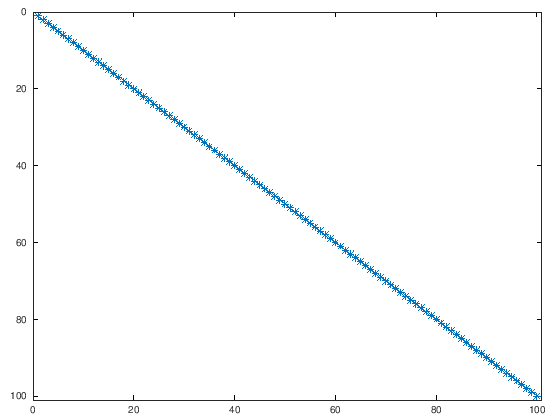

In [16]:
clear all
N=100;
A=eye(N);B=speye(N);
C=[1 0 0; 3 4 -1; 0 22 3];
D=sparse(C)
whos
spy(A) % check the value nz: number of nonzero elements

<b>Problem 1.</b> Write a program which measures the time in MATLAB solving equation $Ax=b$ for $N=2^i,\ i=1,\ldots,12$ if $A=randn(N)$ and $b=(1,\ldots,1)^T\in\mathbb{R}^N$! Make a plot about them!

   2.00   0.00
   4.00   0.00
   8.00   0.00
   16.00    0.00
   32.00    0.00
   64.00    0.00
   128.00     0.00
   256.00     0.00
   512.00     0.02
   1024.00      0.19
   2048.00      0.72
   4096.00      4.31
   8192.00     31.31


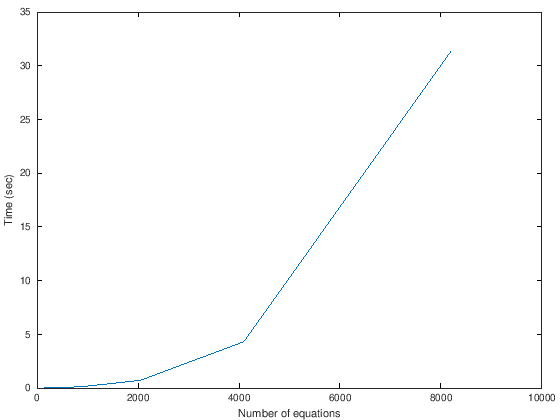

<br>
<b>Problem 2.</b> Make a loglog plot and analyze the results!

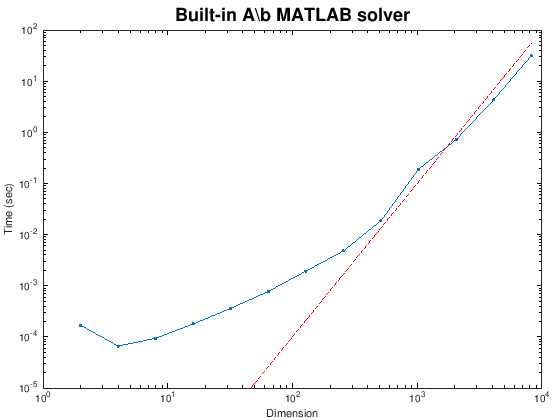

In [4]:
loglog(dim,time,'.-')
hold on 
loglog(dim,1e-10*dim.^3, 'r--')
ylim([1e-5 1e2])
xlabel('Dimension')
ylabel('Time (sec)')
title('Built-in A\b MATLAB solver','fontsize',18)
% gtext('N^3','fontsize',18,'color','k') % Add this line if you have MATLAB

<br>

The <a href="https://www.mathworks.com/help/matlab/ref/mldivide.html">$x=A\backslash b$ algorithm path of MATLAB</a> solving linear equations.
<br>
Dense matrix case
<img src="backslahteli.png" width="400">
<br>
Sparse matrix case
<img src="backslahritka.png" width="400">

<br>
Differences between the commands $\backslash$ and <i><a href="https://www.mathworks.com/help/matlab/ref/linsolve.html">linsolve</a></i> 
<br>

### Classic Iteration Methods for Linear Systems with Symmetric Positive Definite Matrix (Jacobi, GS, SOR)

<br>
Let us consider the following one-step stationary linear iterative form solving equation $Ax=b$

$$x^{(k+1)}=Mx^{(k)}+v,\ \quad k=0,1,\ldots$$<br>

<u>Theorem:</u> The linear iteration consistent with $Ax=b$ iff $\rho(M)<1$<br>

Apply the usual splitting of coefficient matrix $A$, i.e. $A=L+D+U$, where 

+ $L$ is the strictly lower triangular part of $A$
+ $D$ is the diagonal part of $A$
+ $U$ is the strictly upper triangular part of $A$.

<br>
Then the three classic iteration methods are

+ <a href="https://en.wikipedia.org/wiki/Jacobi_method">Jacobi</a>
$$x^{(k+1)}=D^{-1}\big(-[L+U]x^{(k)}+b\big)$$
+ <a href="https://en.wikipedia.org/wiki/Gauss%E2%80%93Seidel_method">Gauss-Seidel</a> (GS)
$$x^{(k+1)}=(L+D)^{-1}\big(-Ux^{(k)}+b\big)$$
+ <a href="https://en.wikipedia.org/wiki/Successive_over-relaxation">SOR</a> (Successive over-relaxation)
$$x^{(k+1)}=(D+\omega L)^{-1}\big(-[\omega U+(\omega -1)D]x^{(k)}+\omega b\big)$$
<br>

<u>Theorem:</u> If the coefficient matrix $A$ is an $M$-matrix, then the Jacobi, GS and SOR iterations for $\omega\in (0,1)$ converge to the true solution of system $Ax=b$ for any initial vector.<br>

<u>Theorem:</u> If the coefficient matrix $A$ is a strictly diagonal dominant matrix, then the Jacobi and GS iterations converge to the true solution of system $Ax=b$ for any initial vector.<br>

<u>Theorem:</u> If the coefficient matrix $A$ is a symmetric positive definite matrix, then the GS iteration and SOR iteration for $\omega\in (0,2)$ converge to the true solution of system $Ax=b$ for any initial vector.<br>

<br>
<b>Problem 3.</b> Write a program which solves the linear system $Ax=b$ by using Jacobi iteration. The first stopping criterion is the relative error of the numerical solution vector in maximum norm taking into account the given tolerance. The second stopping criterion is the number of maximum iteration steps.

In [4]:
format long
N=2^5;
e=ones(N,1);
A=(N+1)^2*spdiags([-e 2*e -e],[-1 0 1],N,N);
b=e;
x0=zeros(length(b),1);
x0(end)=0.01;
[x,it] = jacobi(A,b,x0,10^(-2),200);
it
x

it =  104
x =

   0.00699105354398080
   0.01313178701081495
   0.01850240459244632
   0.02315500052046502
   0.02718088623524459
   0.03061049228659711
   0.03354771146553210
   0.03599366928632738
   0.03806884866345431
   0.03973610652192331
   0.04113857633266689
   0.04219136421503983
   0.04306733615545625
   0.04362507074100920
   0.04407364275872722
   0.04420872044386672
   0.04427935214525807
   0.04401633251724514
   0.04370747688400200
   0.04302318654372882
   0.04228196063073789
   0.04110623390208695
   0.03982927331633681
   0.03804632307143857
   0.03608217782021966
   0.03353286243653460
   0.03068635676564770
   0.02717178505385281
   0.02321063447681457
   0.01849756273109558
   0.01316124028267649
   0.00698954406932624



In [5]:
%% This is required for the loglog plot later on
clear all
format long
N=2^8;
e=ones(N,1);
A=(N+1)^2*spdiags([-e 2*e -e],[-1 0 1],N,N);
b=e;
x0=zeros(length(b),1);
x0(end)=0.01;
for j=1:4
    tic
    [x,it] = jacobi(A,b,x0,10^(-j),10000);
    Jacit(j)=it;
    xmatlab=A\b;
    Jacobi_difference(j)=norm(x-xmatlab,inf);
    Jacobi_time(j)=toc;
end

<br>
<b>Problem 4.</b> [Assignment] Write a program which solves the linear system $Ax=b$ using the GS iteration. The first stopping criterion is the relative error of the numerical solution vector in maximum norm taking into account the given tolerance. The second stopping criterion is the number of maximum iteration steps.

<br>

<br>
<b>Problem 5.</b> [Assignment] Write a program which solves the linear system $Ax=b$ using the SOR iteration. The first stopping criterion is the relative error of the numerical solution vector in maximum norm taking into account the given tolerance. The second stopping criterion is the number of maximum iteration steps.
<br>

<br>
<b>Problem 6.</b> [Assignment] Reproduce the following three loglog plots. Techincal remarks:

+ The relative errors are 1e-1,1e-2,1e-3,1e-4
+ The error vector is measured by the $\backslash$ solution of MATLAB and the appropriate iterative solver's solution
<br>

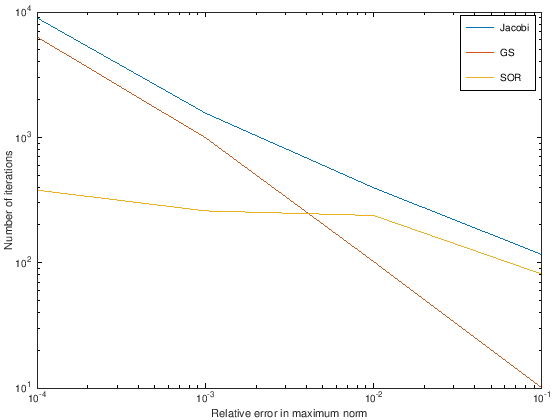

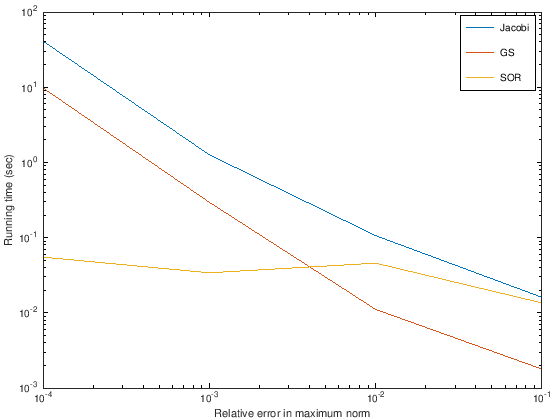

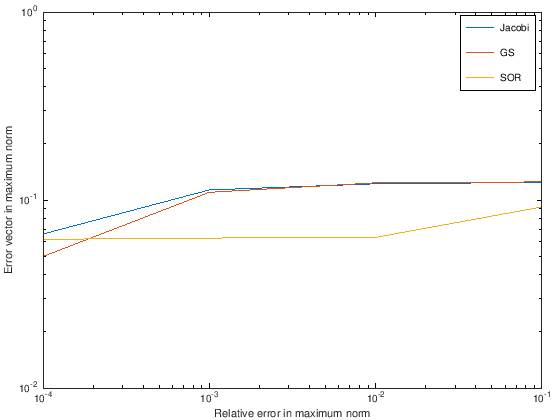

In [11]:
N=2^8;
e=ones(N,1);
A=(N+1)^2*spdiags([-e 2*e -e],[-1 0 1],N,N);
b=e;
x0=zeros(length(b),1);
x0(end)=0.01;
omega=2/(1+sin(pi/(N+1)));
for j=1:10
    tic
    [x,it] = SOR(A,b,x0,omega,10^(-j),10000);
    SORit(j)=it;
    xmatlab=A\b;
    SOR_difference(j)=norm(x-xmatlab,inf);
    SOR_time(j)=toc;
end
SORit

SORit =

    81   238   259   379   516   544   696   773   846   996



<br>

### <a href="https://en.wikipedia.org/wiki/Conjugate_gradient_method">Conjugate Gradient method</a> (CG) 

<br>
<b>Problem 7.</b> Write a program which solves the linear system $Ax=b$ using the CG method. The first stopping criterion is quotient of norms of the residual vector and vector $b$. The second stopping criterion is the number of maximum iteration steps. The outputs are the numerical solution vector $x$, the number of iterations and a safety flag.
<br> 



nit =  73
flag = 0


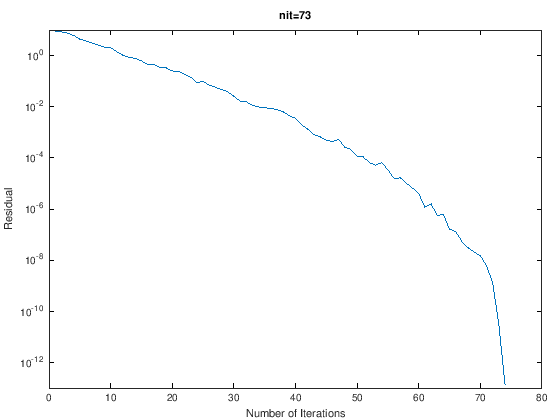

In [13]:
%% Example 1
%A=diag(100:199);
%b=ones(100,1);
%% Example 2
n = 60;
m = 80;
A = randn(n,m);
A = A * A';
b = randn(n,1);
[x,nit,flag] = cg(A,b,1e-12,100);
nit
flag

Elapsed time is 1.6604 seconds.
nit =  16
flag = 0


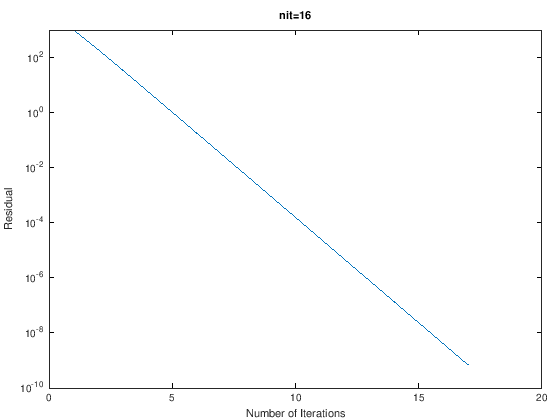

In [14]:
A=diag(sparse(10^6:2*10^6-1));
b=ones(10^6,1);
tic
[x,nit,flag] = cg(A,b,1e-12,100);
toc
nit
flag

<br>

The <a href="https://www.mathworks.com/help/matlab/ref/cgs.html">built-in CG MATLAB solver</a> for square matrices.

In [44]:
n = 60;
m = 80;
A = randn(n,m);
A = A * A';
b = randn(n,1);
cgs(A,b,1e-10,100);

cgs converged at iteration 69 to a solution with relative residual 1.273067e-11


<br>

### <a href="https://en.wikipedia.org/wiki/Preconditioner">Preconditioned Conjugate Gradient</a> method (PCG)

<br>

In [2]:
A=randn(500);
A=A'*A;
b=ones(500,1);
e=eig(A);
lmin=min(e)
lmax=max(e)
kappa=lmax/lmin
cond(A)
sqrt(kappa)

lmin =    2.9414e-04
lmax =  2017.5
kappa =    6.8588e+06
ans =    6.8588e+06
ans =  2618.9


nit =  1350
flag =  1


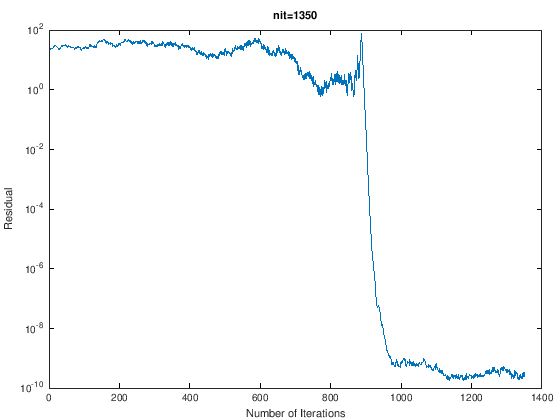

In [3]:
% Kondicioszam fontossaganak megertese
[x,nit,flag] = cg(A,b,1e-12,1350);
nit
flag

<br>
<b>Problem 8.</b> Make experiments with different preconditioners in case of PCG fro the problem $A=\mathrm{diag}(1:100),\ 
b=\mathrm{ones}(100,1)$ and compare the results with results of CG!

<br>

nit =  68
flag = 0


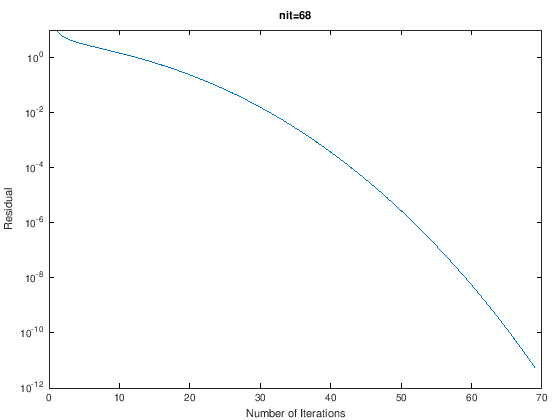

In [4]:
% Toy example when CG is not so fast
A=diag(1:100);
b=ones(100,1);
[x,nit,flag] = cg(A,b,1e-12,1350);
nit
flag

    __line__ at line 120 column 16
    line at line 56 column 8
    __plt__>__plt2vv__ at line 502 column 10
    __plt__>__plt2__ at line 248 column 14
    __plt__>__plt1__ at line 207 column 10
    __plt__ at line 119 column 17
    semilogy at line 60 column 10
    prcg at line 55 column 10
pcg: converged in 33 iterations. pcg: the initial residual norm was reduced 2.75527e+12 times.


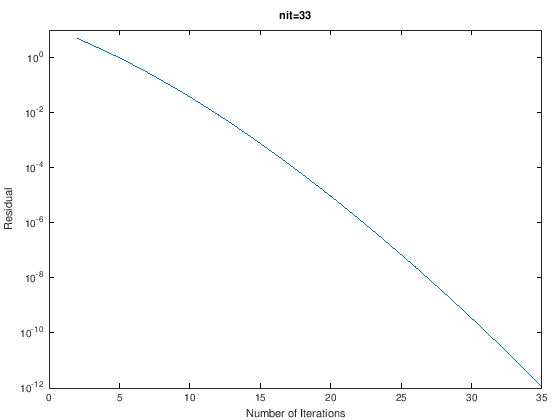

In [9]:
%P=eye(100); 
%P=A;
P=diag(sqrt(1:100)); %Preserve some structure of A
[x, nit] = prcg(A,b,1e-12,1350,P);
pcg(A,b,1e-12,1350,P);

<br>

<b>Problem 9.</b> Let us consider the following sparse and "cookie shape" symmetric matrix. The corresponding MATLAB script is given below.

<br>

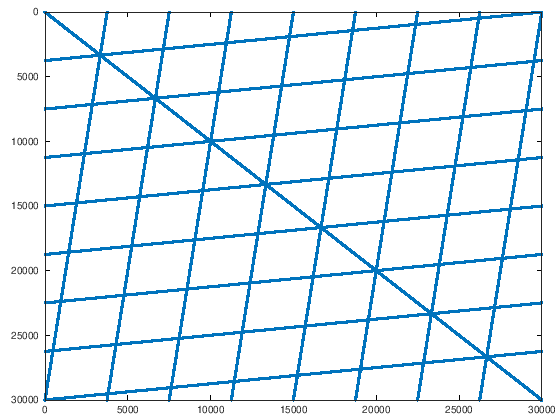

In [10]:
N=30000;
A=spalloc(N,N,4*N);
I=N:N-8:N^2;
A(I)=1;
A=A+A'+diag(sparse(1:N));
spy(A)
b=ones(N,1);

Elapsed time is 3.0402 seconds.
nit =  1193


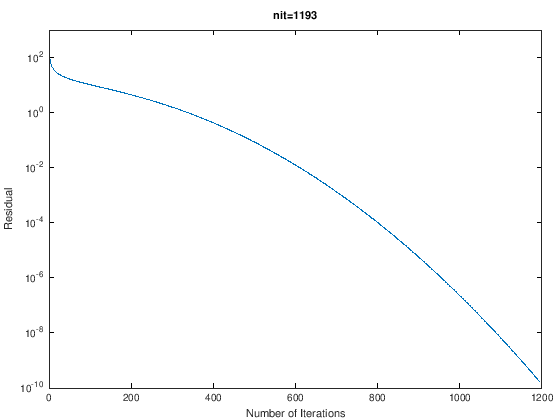

In [11]:
%% Solve the system with CG
tic
[x,nit,flag] = cg(A,b,1e-12,1350);
toc
nit

    __line__ at line 120 column 16
    line at line 56 column 8
    __plt__>__plt2vv__ at line 502 column 10
    __plt__>__plt2__ at line 248 column 14
    __plt__>__plt1__ at line 207 column 10
    __plt__ at line 119 column 17
    semilogy at line 60 column 10
    prcg at line 55 column 10
Elapsed time is 1.05859 seconds.


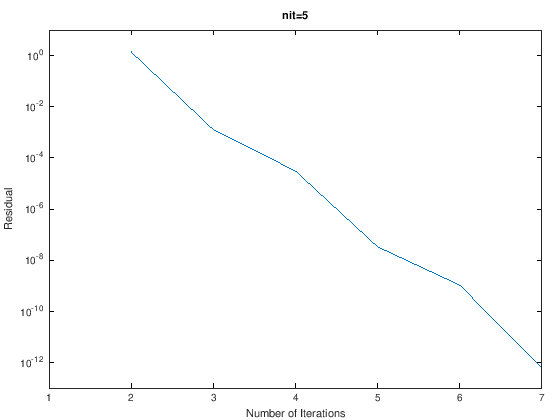

In [12]:
P=diag(diag(A));
tic
[x, nit] = prcg(A,b,1e-12,1350,P);
toc

In [13]:
tic 
xmatlab=A\b;
toc
max(abs(xmatlab-x))

Elapsed time is 0.0619569 seconds.
ans =    5.6066e-15


pcg: converged in 2 iterations. pcg: the initial residual norm was reduced 1.84976e+24 times.
    __line__ at line 120 column 16
    line at line 56 column 8
    __plt__>__plt2vv__ at line 502 column 10
    __plt__>__plt2__ at line 248 column 14
    __plt__>__plt1__ at line 207 column 10
    __plt__ at line 119 column 17
    semilogy at line 60 column 10
    prcg at line 55 column 10


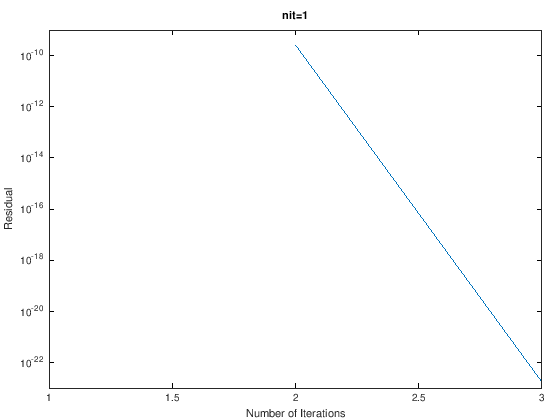

In [14]:
% Toy example when CG is not so fast
N=1000;
e=ones(N,1);
A=(N+1)^2*spdiags([e -2*e e],[-1 0 1],N,N);
b=e;
%P=eye(N);
[x,nit] = cg(A,b,1e-12,1350);
[l, u, p] = ilu (A, struct ("droptol", 1e-12));
x = pcg (A, b, 1e-12,1350, l, u);
prcg(A,b,1e-12,1350,l*u);